In [2]:
import tensorflow as tf
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# =========================
# GPU CHECK
# =========================

In [3]:
print("GPU Available:", tf.config.list_physical_devices('GPU'))


GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# =========================
# DATASET PATHS
# =========================

In [4]:
train_path = r"C:\WORK\CROP-D\DataSet\New Plant Diseases Dataset(Augmented)\train"
valid_path = r"C:\WORK\CROP-D\DataSet\New Plant Diseases Dataset(Augmented)\valid"


# =========================
# DATA AUGMENTATION
# =========================

In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.3,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2
)

valid_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

valid_data = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)


Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


# =========================
# MODEL (MobileNetV2)
# =========================

In [6]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

x = base_model.output
x = GlobalAveragePooling2D()(x)
predictions = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Freeze base model

In [7]:
for layer in base_model.layers:
    layer.trainable = False


# =========================
# COMPILE
# =========================

In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# TRAINING
# =========================

In [9]:
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10
)

Epoch 1/10
2197/2197 [==============================] - 576s 240ms/step - loss: 0.5322 - accuracy: 0.8471 - val_loss: 0.3016 - val_accuracy: 0.9050
Epoch 2/10
2197/2197 [==============================] - 428s 195ms/step - loss: 0.2755 - accuracy: 0.9111 - val_loss: 0.2815 - val_accuracy: 0.9062
Epoch 3/10
2197/2197 [==============================] - 547s 249ms/step - loss: 0.2410 - accuracy: 0.9207 - val_loss: 0.2203 - val_accuracy: 0.9281
Epoch 4/10
2197/2197 [==============================] - 819s 373ms/step - loss: 0.2147 - accuracy: 0.9295 - val_loss: 0.2216 - val_accuracy: 0.9278
Epoch 5/10
2197/2197 [==============================] - 618s 281ms/step - loss: 0.2061 - accuracy: 0.9314 - val_loss: 0.2084 - val_accuracy: 0.9323
Epoch 6/10
2197/2197 [==============================] - 420s 191ms/step - loss: 0.1910 - accuracy: 0.9352 - val_loss: 0.2321 - val_accuracy: 0.9269
Epoch 7/10
2197/2197 [==============================] - 412s 187ms/step - loss: 0.1864 - accuracy: 0.9375 - val_

# =========================
# SAVE MODEL
# =========================

In [10]:
model.save("plant_disease_model.h5")

# =========================
# SAVE CLASS LABELS
# =========================

In [11]:
import json
with open("class_names.json", "w") as f:
    json.dump(train_data.class_indices, f)


# =========================
# PLOT TRAINING GRAPH
# =========================

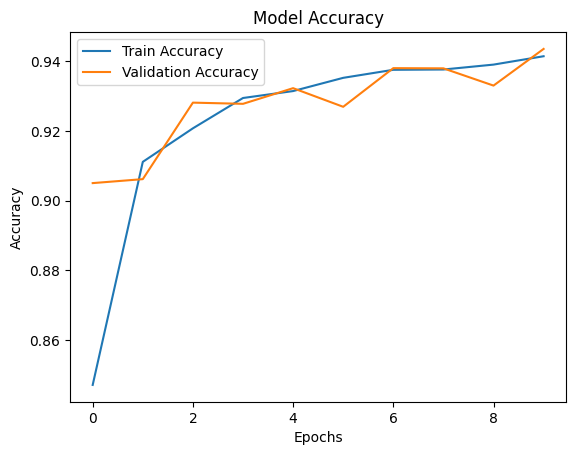

In [12]:
plt.figure()

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.savefig("training_accuracy.png")
plt.show()

# Loss graph

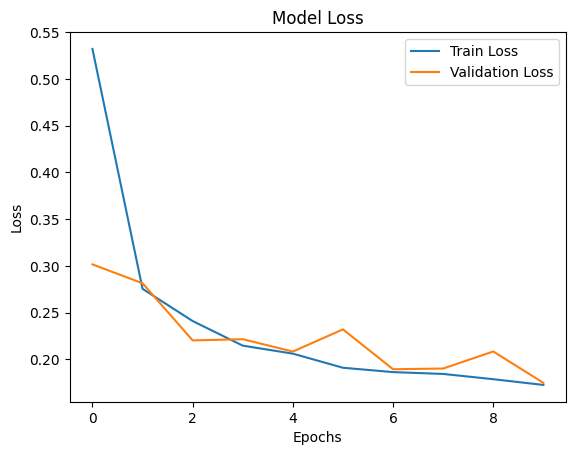

In [13]:

plt.figure()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.savefig("training_loss.png")
plt.show()

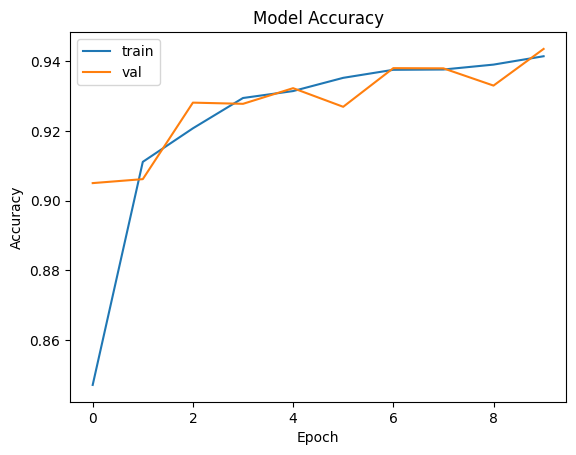

In [14]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['train','val'])
plt.show()

In [15]:
import numpy as np

sample = next(iter(valid_data))[0][0]
sample = np.expand_dims(sample, axis=0)

print(model.predict(sample))

1/1 [==============================] - 1s 725ms/step
[[1.4993633e-06 9.3257182e-07 1.6968202e-06 2.1148252e-09 7.7772242e-12
  9.9999523e-01 1.9538582e-16 1.0870474e-10 2.1915336e-16 2.4106910e-13
  3.8521768e-17 1.8947834e-10 1.9746266e-14 2.7650674e-17 2.6547635e-15
  2.6161091e-11 3.4187156e-10 2.4746288e-12 6.0104651e-07 1.7425997e-09
  1.2930151e-10 5.5293627e-11 1.5704635e-12 3.7648568e-14 1.2732565e-12
  8.7271358e-13 1.1970294e-15 5.3376739e-12 2.9439116e-12 6.4156729e-09
  8.9677232e-10 2.3476532e-10 7.1913066e-11 5.3801902e-10 2.0917312e-08
  2.8139333e-11 2.2581326e-11 4.6733156e-12]]
